# Underfitting, Overfitting, and Regularization — for Classification

Every machine-learning model faces the same balancing act: it must be **complex enough** to learn the real pattern in the data, but **not so complex** that it starts memorizing noise. Get this wrong in either direction and the model fails on new data.

This notebook makes the three cases visible for a **classification** problem, then shows how **regularization** lets us control the balance with a single dial.

**The three cases:**
- **Underfitting** — the model is *too simple*. It misses the real pattern. Bad on training data *and* new data.
- **Good fit** — *just right*. Captures the pattern, ignores the noise. Good on both.
- **Overfitting** — the model is *too complex*. It memorizes the training data, including its random noise. Great on training data, **bad on new data**.

The key idea throughout: **what matters is performance on data the model has never seen** (the test set), not on the data it trained on.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

---
## 1. The data — a problem a straight line can't solve

We use the "two moons" dataset: two interleaving crescent shapes. It's deliberately **non-linear** — no straight line can separate the two classes well — which is exactly what we need to show a model being too simple, just right, and too complex.

We add some **noise** so a few points sit in the "wrong" area. That noise is the trap an overfitting model will fall into.

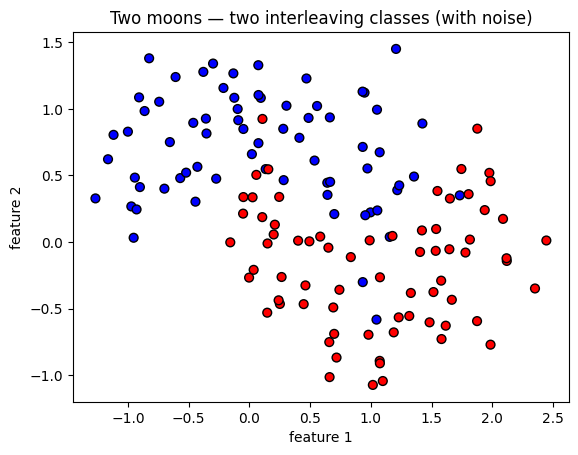

In [16]:
X, y = make_moons(n_samples=200, noise=0.3, random_state=3)

# split into train and test — we judge everything on the unseen test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", edgecolor="k", s=40)
plt.title("Two moons — two interleaving classes (with noise)")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.show()

The two crescents interlock. A good model needs a **curved** boundary to separate them. Let's control how curvy our model is allowed to be, and watch what happens.

---
## 2. A knob for model complexity

We'll use logistic regression, but give it **polynomial features** — extra columns like x², x³, and so on (the trick from polynomial regression). The **degree** controls complexity:
- **degree 1** — only straight lines. Simple. Likely to *underfit*.
- **degree 4** — gentle curves. Probably *just right*.
- **degree 15** — wildly flexible curves. Likely to *overfit*.

Let's build a helper that trains a model of a given degree and draws its decision boundary.

In [17]:
def train_and_plot(degree, C=1e6, ax=None):
    # C=1e6 means "almost no regularization" for now — we add that later
    model = make_pipeline(
        PolynomialFeatures(degree),
        LogisticRegression(C=C, max_iter=5000)
    )
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))

    # draw the decision boundary
    if ax is None:
        ax = plt.gca()
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 300),
        np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="bwr")
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", edgecolor="k", s=25)
    ax.set_title(f"degree {degree}\ntrain {train_acc:.0%}  |  test {test_acc:.0%}")
    ax.set_xticks([]); ax.set_yticks([])
    return train_acc, test_acc

---
## 3. Underfit, good fit, overfit — side by side

Now the payoff. Train all three complexities and compare their boundaries **and** their train-vs-test accuracy.

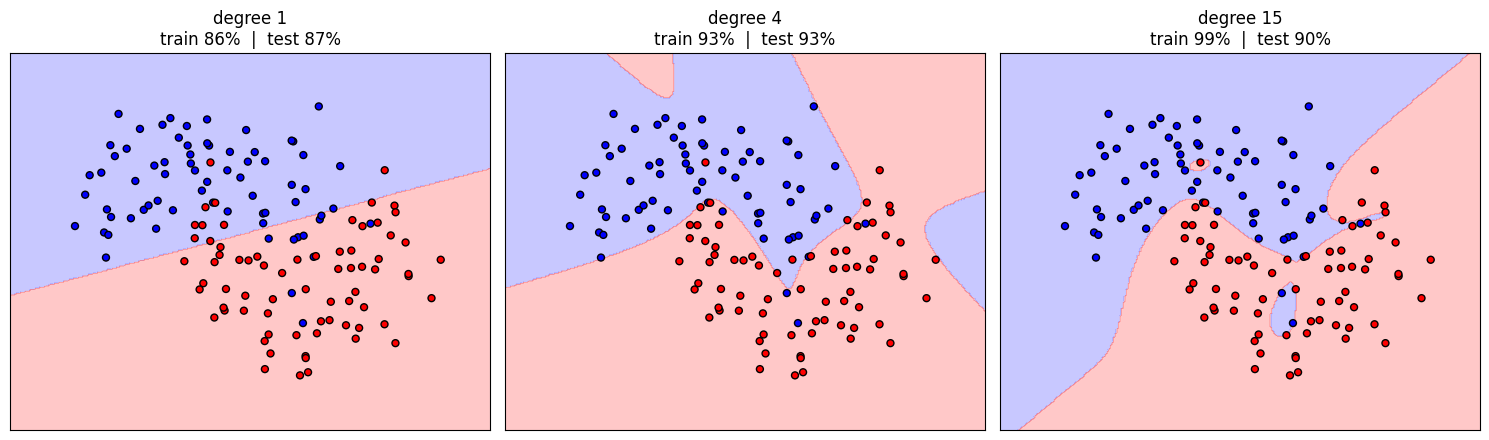

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
results = {}
for ax, degree in zip(axes, [1, 4, 15]):
    tr, te = train_and_plot(degree, ax=ax)
    results[degree] = (tr, te)
plt.tight_layout()
plt.show()

Look at the three boundaries:

- **degree 1 (underfit)** — a rigid straight line. It can't bend to follow the crescents, so it misclassifies whole chunks. Notice train and test accuracy are **both mediocre** — the model is too simple to capture the pattern at all.

- **degree 4 (good fit)** — a smooth curve that follows the two moons naturally. Train and test accuracy are **both high and close together**. This is what we want.

- **degree 15 (overfit)** — a chaotic boundary with strange islands and pockets, contorting itself to capture individual noisy points. Its **train accuracy is highest of all**, but look at the **test accuracy — it drops.** The model memorized the training noise and fails on new data.

In [18]:
# Put the numbers side by side — this table IS the lesson
print(f"{'model':<20} {'train acc':>10} {'test acc':>10} {'gap':>8}")
print("-" * 50)
for degree, (tr, te) in results.items():
    label = {1: "degree 1 (underfit)", 4: "degree 4 (good)", 15: "degree 15 (overfit)"}[degree]
    print(f"{label:<20} {tr:>10.1%} {te:>10.1%} {tr-te:>+8.1%}")

model                 train acc   test acc      gap
--------------------------------------------------
degree 1 (underfit)       86.4%      86.7%    -0.2%
degree 4 (good)           92.9%      93.3%    -0.5%
degree 15 (overfit)       98.6%      90.0%    +8.6%


**The gap between train and test accuracy is the tell-tale sign:**
- underfit → both low, small gap (the model is just weak everywhere),
- good fit → both high, small gap,
- overfit → **large gap** (great on train, worse on test). That widening gap is the fingerprint of overfitting.

A model that scores 98% on training data but 88% on test data hasn't learned the pattern — it has *memorized the answers*, like a student who crammed the exact past-paper questions but can't handle a new one.

---
## 4. Controlling overfitting with regularization

Here's the practical question: the degree-15 model is too flexible, but sometimes we can't just "make the model simpler" — real models are complex. Instead we use **regularization**: a way to *keep* a flexible model but **discourage it from becoming extreme.**

**The idea in plain words:** overfitting happens when the model gives some features enormous weights to twist the boundary through every point. Regularization adds a penalty for large weights — it tells the model *"you may use these features, but keep the weights small and reasonable unless the data really justifies otherwise."* This smooths the boundary without changing the model's structure.

In scikit-learn's `LogisticRegression`, the strength is set by **C**, which works *backwards* (it's the inverse of regularization strength):
- **small C** (e.g. 0.001) → **strong** regularization → simpler, smoother boundary,
- **large C** (e.g. 1000) → **weak** regularization → the model is free to overfit.

Let's take the **same overfitting degree-15 model** and vary only C.

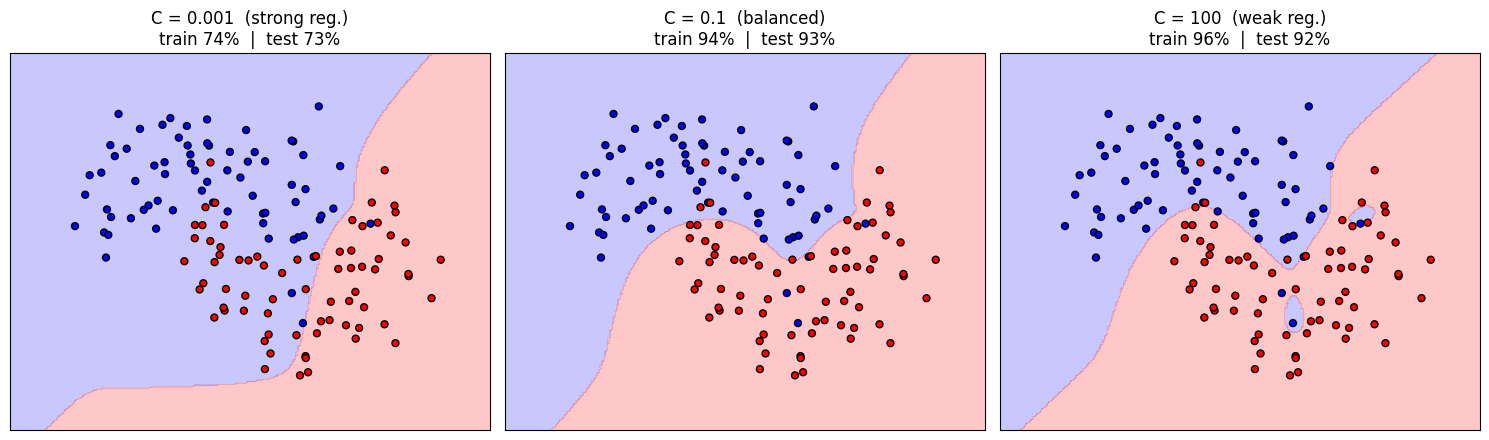

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
reg_results = {}
for ax, C in zip(axes, [0.001, 0.1, 100]):
    model = make_pipeline(PolynomialFeatures(15), LogisticRegression(C=C, max_iter=5000))
    model.fit(X_train, y_train)
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test, model.predict(X_test))
    reg_results[C] = (tr, te)

    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 300),
        np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="bwr")
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", edgecolor="k", s=25)
    strength = {0.001: "strong reg.", 0.1: "balanced", 100: "weak reg."}[C]
    ax.set_title(f"C = {C}  ({strength})\ntrain {tr:.0%}  |  test {te:.0%}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Same degree-15 model in all three — **only C changed:**

- **C = 0.001 (strong regularization)** — the penalty is so heavy the boundary is forced almost straight. We've *over*-regularized: it now **underfits**, just like degree 1.
- **C = 0.1 (balanced)** — the penalty tames the wild wiggles into a smooth, sensible curve. Even though the model *could* be complex, regularization keeps it reasonable. **Test accuracy is back up** — this is the sweet spot.
- **C = 100 (weak regularization)** — barely any penalty, so the model is free to overfit again, with the contorted islands returning.

Regularization gave us a **dial** to slide between too-simple and too-complex, *without changing the model itself.*

In [19]:
# the numbers confirm it
print(f"{'setting':<28} {'train acc':>10} {'test acc':>10} {'gap':>8}")
print("-" * 58)
for C, (tr, te) in reg_results.items():
    label = {0.001: "C=0.001 (strong reg → underfit)",
             0.1: "C=0.1 (balanced → good)",
             100: "C=100 (weak reg → overfit)"}[C]
    print(f"{label:<28} {tr:>10.1%} {te:>10.1%} {tr-te:>+8.1%}")

setting                       train acc   test acc      gap
----------------------------------------------------------
C=0.001 (strong reg → underfit)      74.3%      73.3%    +1.0%
C=0.1 (balanced → good)           94.3%      93.3%    +1.0%
C=100 (weak reg → overfit)        95.7%      91.7%    +4.0%


Read the gap column again: strong regularization gives a small gap but low accuracy (underfit); balanced gives high accuracy and a small gap (good); weak regularization gives the widest gap (overfit). **The balanced setting wins on the test set** — which is the only score that matters.

---
## 5. Finding the best C automatically

Rather than eyeballing three values, we can sweep many values of C and plot train vs test accuracy. The best C is where **test** accuracy peaks.

c:\Users\Abbas\anaconda3\envs\imageenv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


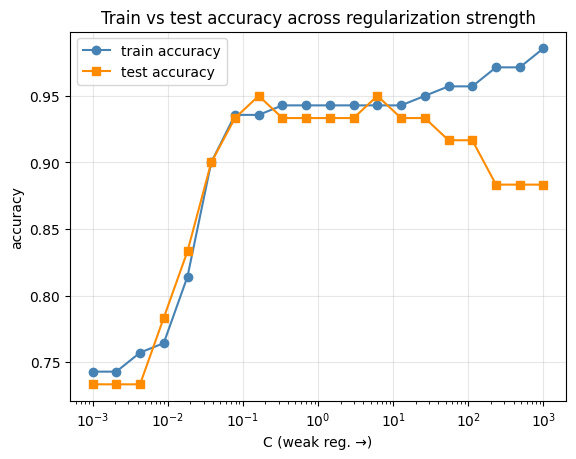

best C (highest test accuracy): 0.162


In [10]:
C_values = np.logspace(-3, 3, 20)   # from 0.001 to 1000
train_scores, test_scores = [], []

for C in C_values:
    model = make_pipeline(PolynomialFeatures(15), LogisticRegression(C=C, max_iter=5000))
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(C_values, train_scores, "o-", label="train accuracy", color="steelblue")
plt.plot(C_values, test_scores, "s-", label="test accuracy", color="darkorange")
plt.xscale("log")
plt.xlabel("C (weak reg. →)"); plt.ylabel("accuracy")
plt.title("Train vs test accuracy across regularization strength")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

best_C = C_values[np.argmax(test_scores)]
print(f"best C (highest test accuracy): {best_C:.3f}")

This plot is the whole story of the notebook in one picture:

- On the **left** (small C, strong regularization): both curves are low — **underfitting**. The model is too constrained.
- In the **middle**: test accuracy peaks — the **sweet spot**.
- On the **right** (large C, weak regularization): train accuracy keeps climbing but test accuracy **falls or flattens**, and the two curves **diverge** — **overfitting**.

The gap between the blue (train) and orange (test) curves *is* overfitting, made visible. The best model is where the orange test curve is highest — not where the blue train curve is highest.

---
## Summary

- **Underfitting**: model too simple → misses the pattern → poor on *both* train and test data.
- **Overfitting**: model too complex → memorizes training noise → great on train, **poor on test**. The tell-tale sign is a **large gap** between train and test accuracy.
- **Good fit**: captures the real pattern, ignores the noise → high on both, small gap.
- **What matters is test performance** — the score on data the model has never seen. A high training score alone means nothing.
- **Regularization** is a dial that controls complexity *without changing the model*. It penalizes extreme weights, smoothing the boundary. In `LogisticRegression`, **C** sets the strength: **small C = strong regularization (simpler)**, **large C = weak regularization (freer to overfit)**.
- Sweep C and pick the value where **test accuracy peaks** — that's the best balance.

This under/over-fitting trade-off appears in *every* model you'll ever use — logistic regression, SVM (its C and gamma), decision trees (their depth), neural networks. The names of the knobs change; the balancing act is always the same.